In [11]:
#!pip install -q kaggle

In [12]:
#!pip install -q kagglehub

In [13]:
#import kagglehub

#kagglehub.login()

In [14]:
#import sys
#print(sys.executable)

In [15]:
#!kaggle datasets download -d antoreepjana/animals-detection-images-dataset

In [16]:
#!unzip -q animals-detection-images-dataset.zip -d wildlife_dataset

In [17]:
#!head -5 wildlife_dataset/test/Deer/Label/ea788970a9fb822c.txt

In [18]:
from pathlib import Path
from PIL import Image
import shutil

ROOT = Path.cwd()

SOURCE_ROOT = Path("/teamspace/studios/this_studio/wildlife_dataset")
YOLO_ROOT = Path("/teamspace/studios/this_studio/wildlife_yolo")

CLASS_NAMES = [
    "Bear", "Brown bear", "Bull", "Butterfly", "Camel", "Canary",
    "Caterpillar", "Cattle", "Centipede", "Cheetah", "Chicken", "Crab",
    "Crocodile", "Deer", "Duck", "Eagle", "Elephant", "Fish", "Fox",
    "Frog", "Giraffe", "Goat", "Goldfish", "Goose", "Hamster",
    "Harbor seal", "Hedgehog", "Hippopotamus", "Horse", "Jaguar",
    "Jellyfish", "Kangaroo", "Koala", "Ladybug", "Leopard", "Lion",
    "Lizard", "Lynx", "Magpie", "Monkey", "Moths and butterflies",
    "Mouse", "Mule", "Ostrich", "Otter", "Owl", "Panda", "Parrot",
    "Penguin", "Pig", "Polar bear", "Rabbit", "Raccoon", "Raven",
    "Red panda", "Rhinoceros", "Scorpion", "Sea lion", "Sea turtle",
    "Seahorse", "Shark", "Sheep", "Shrimp", "Snail", "Snake",
    "Sparrow", "Spider", "Squid", "Squirrel", "Starfish", "Swan",
    "Tick", "Tiger", "Tortoise", "Turkey", "Turtle", "Whale",
    "Woodpecker", "Worm", "Zebra"
]

CLASS_TO_ID = {
    class_name: class_id
    for class_id, class_name in enumerate(CLASS_NAMES)
}

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("Source:", SOURCE_ROOT)
print("Output:", YOLO_ROOT)

if not SOURCE_ROOT.exists():
    raise FileNotFoundError(f"Dataset folder not found: {SOURCE_ROOT}")

if YOLO_ROOT.exists():
    shutil.rmtree(YOLO_ROOT)

for split in ["train", "test"]:
    image_output_dir = YOLO_ROOT / "images" / split
    label_output_dir = YOLO_ROOT / "labels" / split

    image_output_dir.mkdir(parents=True, exist_ok=True)
    label_output_dir.mkdir(parents=True, exist_ok=True)

    converted_images = 0
    converted_boxes = 0
    skipped_lines = 0

    split_root = SOURCE_ROOT / split

    if not split_root.exists():
        raise FileNotFoundError(f"Split folder not found: {split_root}")

    for class_folder in sorted(split_root.iterdir()):
        if not class_folder.is_dir():
            continue

        label_folder = class_folder / "Label"

        for image_path in class_folder.iterdir():
            if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
                continue

            label_path = label_folder / f"{image_path.stem}.txt"

            output_image_path = image_output_dir / image_path.name
            output_label_path = label_output_dir / f"{image_path.stem}.txt"

            shutil.copy2(image_path, output_image_path)

            with Image.open(image_path) as image:
                image_width, image_height = image.size

            yolo_lines = []

            if label_path.exists():
                text = label_path.read_text().strip()

                if text:
                    for line in text.splitlines():
                        parts = line.split()

                        if len(parts) < 5:
                            skipped_lines += 1
                            continue

                        class_name = " ".join(parts[:-4])

                        try:
                            xmin, ymin, xmax, ymax = map(float, parts[-4:])
                        except ValueError:
                            skipped_lines += 1
                            continue

                        if class_name not in CLASS_TO_ID:
                            skipped_lines += 1
                            continue

                        xmin = max(0, min(xmin, image_width))
                        ymin = max(0, min(ymin, image_height))
                        xmax = max(0, min(xmax, image_width))
                        ymax = max(0, min(ymax, image_height))

                        box_width = xmax - xmin
                        box_height = ymax - ymin

                        if box_width <= 0 or box_height <= 0:
                            skipped_lines += 1
                            continue

                        x_center = ((xmin + xmax) / 2) / image_width
                        y_center = ((ymin + ymax) / 2) / image_height
                        width = box_width / image_width
                        height = box_height / image_height

                        class_id = CLASS_TO_ID[class_name]

                        yolo_lines.append(
                            f"{class_id} "
                            f"{x_center:.6f} "
                            f"{y_center:.6f} "
                            f"{width:.6f} "
                            f"{height:.6f}"
                        )

                        converted_boxes += 1

            output_label_path.write_text("\n".join(yolo_lines))
            converted_images += 1

    print(f"\n{split.upper()}")
    print("Converted images:", converted_images)
    print("Converted boxes:", converted_boxes)
    print("Skipped annotation lines:", skipped_lines)

Source: /teamspace/studios/this_studio/wildlife_dataset
Output: /teamspace/studios/this_studio/wildlife_yolo



TRAIN
Converted images: 22566
Converted boxes: 28214
Skipped annotation lines: 0

TEST
Converted images: 6505
Converted boxes: 7576
Skipped annotation lines: 0


In [19]:
from pathlib import Path
from collections import Counter


CLASS_NAMES = [
    "Bear", "Brown bear", "Bull", "Butterfly", "Camel", "Canary",
    "Caterpillar", "Cattle", "Centipede", "Cheetah", "Chicken", "Crab",
    "Crocodile", "Deer", "Duck", "Eagle", "Elephant", "Fish", "Fox",
    "Frog", "Giraffe", "Goat", "Goldfish", "Goose", "Hamster",
    "Harbor seal", "Hedgehog", "Hippopotamus", "Horse", "Jaguar",
    "Jellyfish", "Kangaroo", "Koala", "Ladybug", "Leopard", "Lion",
    "Lizard", "Lynx", "Magpie", "Monkey", "Moths and butterflies",
    "Mouse", "Mule", "Ostrich", "Otter", "Owl", "Panda", "Parrot",
    "Penguin", "Pig", "Polar bear", "Rabbit", "Raccoon", "Raven",
    "Red panda", "Rhinoceros", "Scorpion", "Sea lion", "Sea turtle",
    "Seahorse", "Shark", "Sheep", "Shrimp", "Snail", "Snake",
    "Sparrow", "Spider", "Squid", "Squirrel", "Starfish", "Swan",
    "Tick", "Tiger", "Tortoise", "Turkey", "Turtle", "Whale",
    "Woodpecker", "Worm", "Zebra"
]

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

errors = []
empty_labels = []
class_counts = Counter()

for split in ["train", "test"]:
    image_dir = YOLO_ROOT / "images" / split
    label_dir = YOLO_ROOT / "labels" / split

    images = [
        path for path in image_dir.rglob("*")
        if path.suffix.lower() in IMAGE_EXTENSIONS
    ]

    labels = list(label_dir.rglob("*.txt"))

    image_stems = {path.stem for path in images}
    label_stems = {path.stem for path in labels}

    print(f"\n{split.upper()}")
    print("Images:", len(images))
    print("Labels:", len(labels))
    print("Images without labels:", len(image_stems - label_stems))
    print("Labels without images:", len(label_stems - image_stems))

    for label_path in labels:
        text = label_path.read_text().strip()

        if not text:
            empty_labels.append(label_path)
            continue

        for line_number, line in enumerate(text.splitlines(), start=1):
            parts = line.split()

            if len(parts) != 5:
                errors.append(
                    f"{label_path}, line {line_number}: "
                    f"expected 5 values, found {len(parts)}"
                )
                continue

            try:
                class_id = int(parts[0])
                x_center, y_center, width, height = map(float, parts[1:])
            except ValueError:
                errors.append(
                    f"{label_path}, line {line_number}: invalid values"
                )
                continue

            if not 0 <= class_id < len(CLASS_NAMES):
                errors.append(
                    f"{label_path}, line {line_number}: "
                    f"invalid class ID {class_id}"
                )
                continue

            class_counts[class_id] += 1

            if not all(
                0 <= value <= 1
                for value in [x_center, y_center, width, height]
            ):
                errors.append(
                    f"{label_path}, line {line_number}: "
                    "values outside [0, 1]"
                )

            if width <= 0 or height <= 0:
                errors.append(
                    f"{label_path}, line {line_number}: "
                    "non-positive width or height"
                )

            x_min = x_center - width / 2
            y_min = y_center - height / 2
            x_max = x_center + width / 2
            y_max = y_center + height / 2

            tolerance = 1e-5

            if (
                x_min < -tolerance or
                y_min < -tolerance or
                x_max > 1 + tolerance or
                y_max > 1 + tolerance
            ):
                errors.append(
                    f"{label_path}, line {line_number}: "
                    "box extends outside image"
                )

print("\n" + "=" * 50)
print("Actual conversion errors:", len(errors))
print("Empty label files:", len(empty_labels))

for error in errors[:20]:
    print("-", error)

print("\nBounding boxes per class:")

for class_id, class_name in enumerate(CLASS_NAMES):
    print(f"{class_id:2d} | {class_name:22s} | {class_counts[class_id]}")


TRAIN
Images: 21649
Labels: 21649
Images without labels: 0
Labels without images: 0

TEST
Images: 6003
Labels: 6003
Images without labels: 0
Labels without images: 0

Actual conversion errors: 0
Empty label files: 0

Bounding boxes per class:
 0 | Bear                   | 125
 1 | Brown bear             | 155
 2 | Bull                   | 60
 3 | Butterfly              | 2922
 4 | Camel                  | 123
 5 | Canary                 | 129
 6 | Caterpillar            | 525
 7 | Cattle                 | 276
 8 | Centipede              | 220
 9 | Cheetah                | 83
10 | Chicken                | 596
11 | Crab                   | 451
12 | Crocodile              | 184
13 | Deer                   | 655
14 | Duck                   | 838
15 | Eagle                  | 923
16 | Elephant               | 212
17 | Fish                   | 2459
18 | Fox                    | 222
19 | Frog                   | 676
20 | Giraffe                | 360
21 | Goat                   | 302
22 | Gol

In [20]:
from pathlib import Path
import random
import shutil


train_images = YOLO_ROOT / "images/train"
train_labels = YOLO_ROOT / "labels/train"

val_images = YOLO_ROOT / "images/val"
val_labels = YOLO_ROOT / "labels/val"

val_images.mkdir(parents=True, exist_ok=True)
val_labels.mkdir(parents=True, exist_ok=True)

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

images = [
    path for path in train_images.iterdir()
    if path.suffix.lower() in IMAGE_EXTENSIONS
]

random.seed(42)
random.shuffle(images)

val_count = int(len(images) * 0.10)
selected_images = images[:val_count]

for image_path in selected_images:
    label_path = train_labels / f"{image_path.stem}.txt"

    shutil.move(str(image_path), str(val_images / image_path.name))
    shutil.move(str(label_path), str(val_labels / label_path.name))

print("Images moved to validation:", len(selected_images))
print("Remaining training images:", len(list(train_images.iterdir())))
print("Validation images:", len(list(val_images.iterdir())))

Images moved to validation: 2164
Remaining training images: 19485
Validation images: 2164


In [21]:
for split in ["train", "val", "test"]:
    image_count = len([
        path for path in (YOLO_ROOT / "images" / split).iterdir()
        if path.suffix.lower() in IMAGE_EXTENSIONS
    ])

    label_count = len(list(
        (YOLO_ROOT / "labels" / split).glob("*.txt")
    ))

    print(f"{split}: {image_count} images, {label_count} labels")

train: 19485 images, 19485 labels
val: 2164 images, 2164 labels
test: 6003 images, 6003 labels


In [22]:
import yaml
from pathlib import Path

data = {
    "path": str(YOLO_ROOT),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": CLASS_NAMES
}

with open(YOLO_ROOT / "dataset.yaml", "w") as f:
    yaml.safe_dump(data, f, sort_keys=False)

print("dataset.yaml created!")

dataset.yaml created!


In [23]:
#!pip install -U ultralytics

In [24]:
from ultralytics import YOLO

model = YOLO("yolo26s.pt")
print("Model loaded successfully!")

Model loaded successfully!


In [26]:
results = model.train(
    data="/teamspace/studios/this_studio/wildlife_yolo/dataset.yaml",
    epochs=40,
    imgsz=512,
    batch=96,
    device=0,
    workers=8,
    amp=True,
    compile=True,
    cache=False,
    patience=10,
    project="/teamspace/studios/this_studio/runs",
    name="yolo26s_512_a100_batch96"
)

Ultralytics 8.4.92 🚀 Python-3.12.11 torch-2.8.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81152MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=96, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=True, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/teamspace/studios/this_studio/wildlife_yolo/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26s_512_a100_batch96, nbs=64, nms=False, 

YOLO26s summary: 260 layers, 10,009,784 parameters, 10,009,784 gradients, 22.8 GFLOPs

Transferred 708/708 items from pretrained weights
compile: starting torch.compile with 'default' mode...
compile: compile complete in 1.8s (no warmup)
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2798.8±1073.2 MB/s, size: 358.1 KB)
train: Scanning /teamspace/studios/this_studio/wildlife_yolo/labels/train.cache... 19485 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 19485/19485 4.8Git/s 0.0s
train: /teamspace/studios/this_studio/wildlife_yolo/images/train/326b9a3496142b2e.jpg: 1 duplicate labels removed
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 457.9±131.8 MB/s, size: 232.2 KB)
val: Scanning /teamspace/studios/this_studio/wildlife_yolo/labels/val.cache... 2164 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2164/2164 129.7Mit/s 0.0s
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.

In [27]:
from shutil import make_archive

make_archive(
    "/teamspace/studios/this_studio/yolo26s_512_a100_batch96",
    "zip",
    "/teamspace/studios/this_studio/runs/yolo26s_512_a100_batch96"
)

'/teamspace/studios/this_studio/yolo26s_512_a100_batch96.zip'

In [28]:
from IPython.display import FileLink

FileLink("/teamspace/studios/this_studio/yolo26s_512_a100_batch96.zip")

/teamspace/studios/this_studio/yolo26s_512_a100_batch96.zip

In [29]:
import zipfile

with zipfile.ZipFile("yolo26s_512_a100_batch96.zip", "r") as zip_ref:
    zip_ref.extractall("yolo26s_512_a100_batch96")

In [30]:
from ultralytics import YOLO

model = YOLO(
    "/teamspace/studios/this_studio/yolo26s_512_a100_batch96/weights/best.pt"
)

test_results = model.val(
    data="/teamspace/studios/this_studio/wildlife_yolo/dataset.yaml",
    split="test",
    imgsz=512,
    batch=96,
    device=0
)

Ultralytics 8.4.92 🚀 Python-3.12.11 torch-2.8.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81152MiB)
YOLO26s summary (fused): 122 layers, 9,496,140 parameters, 0 gradients, 20.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2259.8±657.4 MB/s, size: 194.1 KB)
val: Scanning /teamspace/studios/this_studio/wildlife_yolo/labels/test... 6003 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 6003/6003 1.0Kit/s 5.8s0.0ss
val: New cache created: /teamspace/studios/this_studio/wildlife_yolo/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 2.2it/s 28.7s0.4ss
                   all       6003       6973       0.67       0.62      0.659      0.584
                  Bear         27         30       0.53        0.6      0.586      0.533
            Brown bear         37         42       0.75      0.548      0.754      0.733
                  Bull         18         22      0.272      0.318      0.213       0.17


In [31]:
from pathlib import Path
from collections import Counter

CLASS_NAMES = [
    "Bear", "Brown bear", "Bull", "Butterfly", "Camel", "Canary",
    "Caterpillar", "Cattle", "Centipede", "Cheetah", "Chicken", "Crab",
    "Crocodile", "Deer", "Duck", "Eagle", "Elephant", "Fish", "Fox",
    "Frog", "Giraffe", "Goat", "Goldfish", "Goose", "Hamster",
    "Harbor seal", "Hedgehog", "Hippopotamus", "Horse", "Jaguar",
    "Jellyfish", "Kangaroo", "Koala", "Ladybug", "Leopard", "Lion",
    "Lizard", "Lynx", "Magpie", "Monkey", "Moths and butterflies",
    "Mouse", "Mule", "Ostrich", "Otter", "Owl", "Panda", "Parrot",
    "Penguin", "Pig", "Polar bear", "Rabbit", "Raccoon", "Raven",
    "Red panda", "Rhinoceros", "Scorpion", "Sea lion", "Sea turtle",
    "Seahorse", "Shark", "Sheep", "Shrimp", "Snail", "Snake",
    "Sparrow", "Spider", "Squid", "Squirrel", "Starfish", "Swan",
    "Tick", "Tiger", "Tortoise", "Turkey", "Turtle", "Whale",
    "Woodpecker", "Worm", "Zebra"
]

labels_dir = Path(
    "/teamspace/studios/this_studio/wildlife_yolo/labels/train"
)

counts = Counter()

for label_file in labels_dir.glob("*.txt"):
    for line in label_file.read_text().splitlines():
        if line.strip():
            class_id = int(line.split()[0])
            counts[class_id] += 1

for class_id, count in sorted(counts.items(), key=lambda x: x[1]):
    print(f"{CLASS_NAMES[class_id]:25} {count}")

Seahorse                  6
Squid                     15
Hamster                   15
Turtle                    25
Bull                      35
Shrimp                    37
Jaguar                    41
Red panda                 46
Koala                     52
Magpie                    59
Raven                     61
Otter                     63
Cattle                    63
Lynx                      69
Mule                      69
Cheetah                   70
Hippopotamus              71
Hedgehog                  72
Scorpion                  75
Camel                     81
Tick                      82
Bear                      87
Panda                     89
Turkey                    91
Crocodile                 93
Kangaroo                  95
Raccoon                   98
Brown bear                100
Sea turtle                100
Canary                    106
Harbor seal               110
Leopard                   112
Fox                       128
Mouse                     132
Sheep   

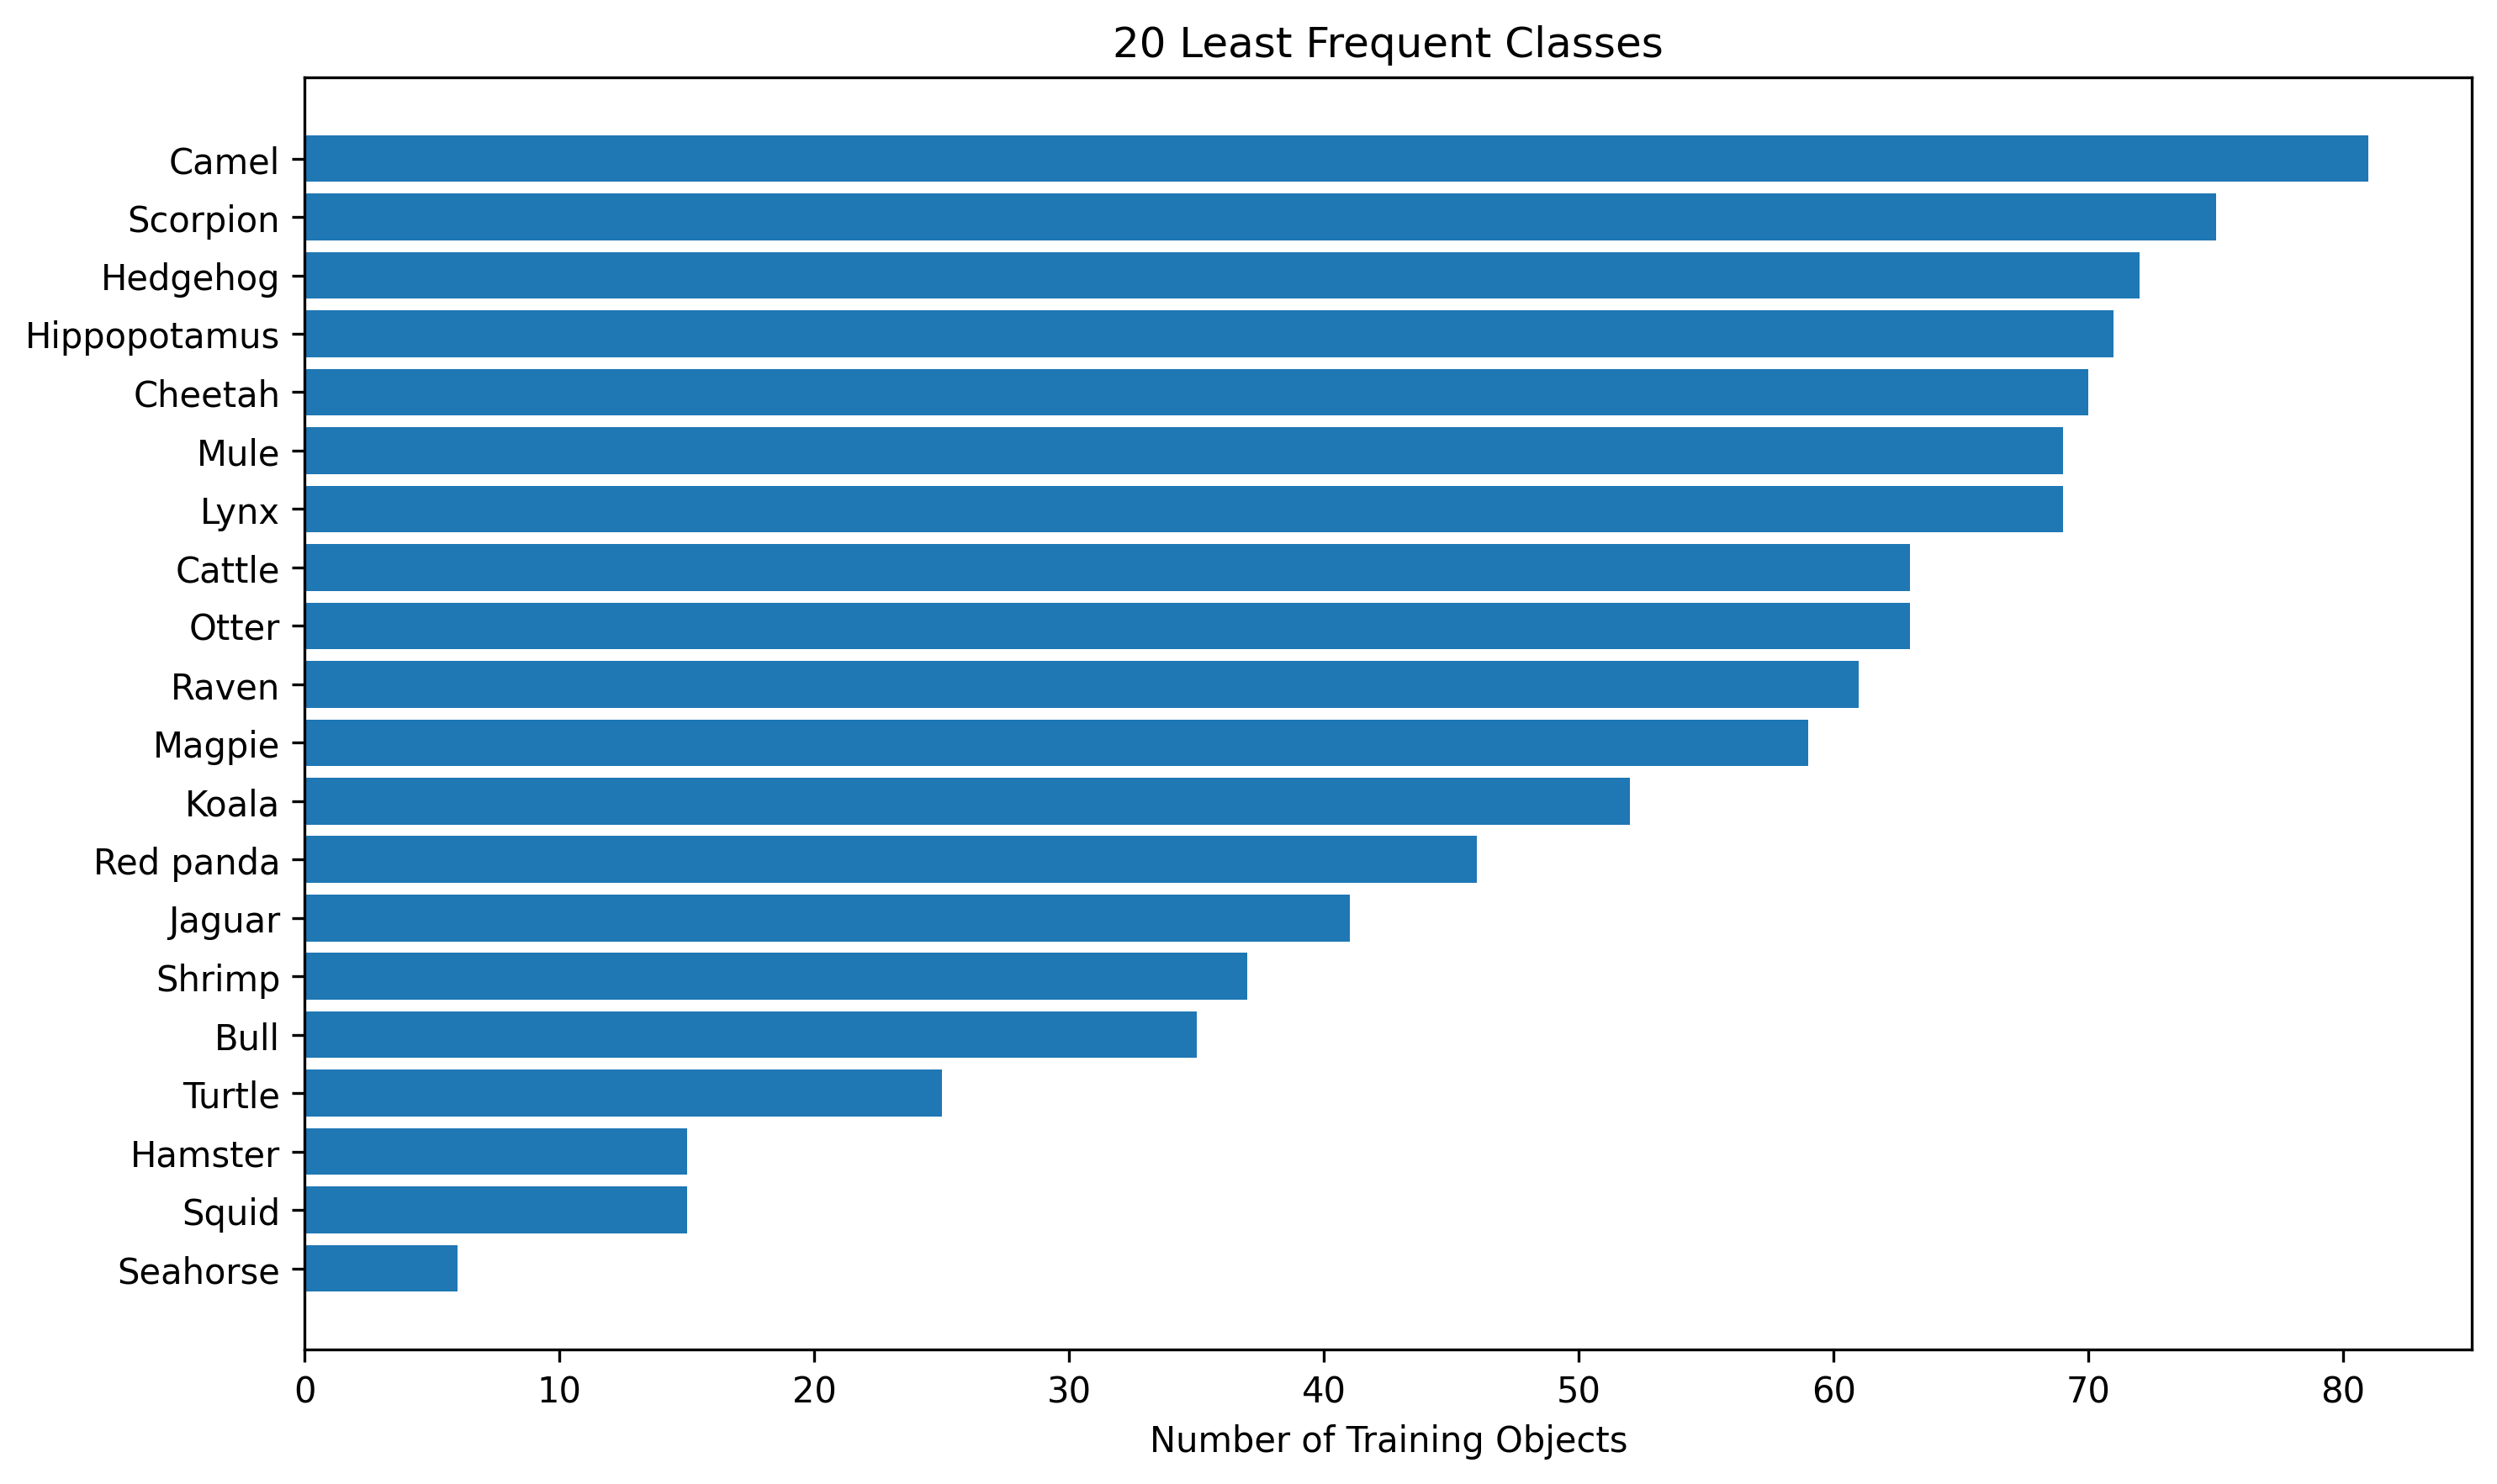

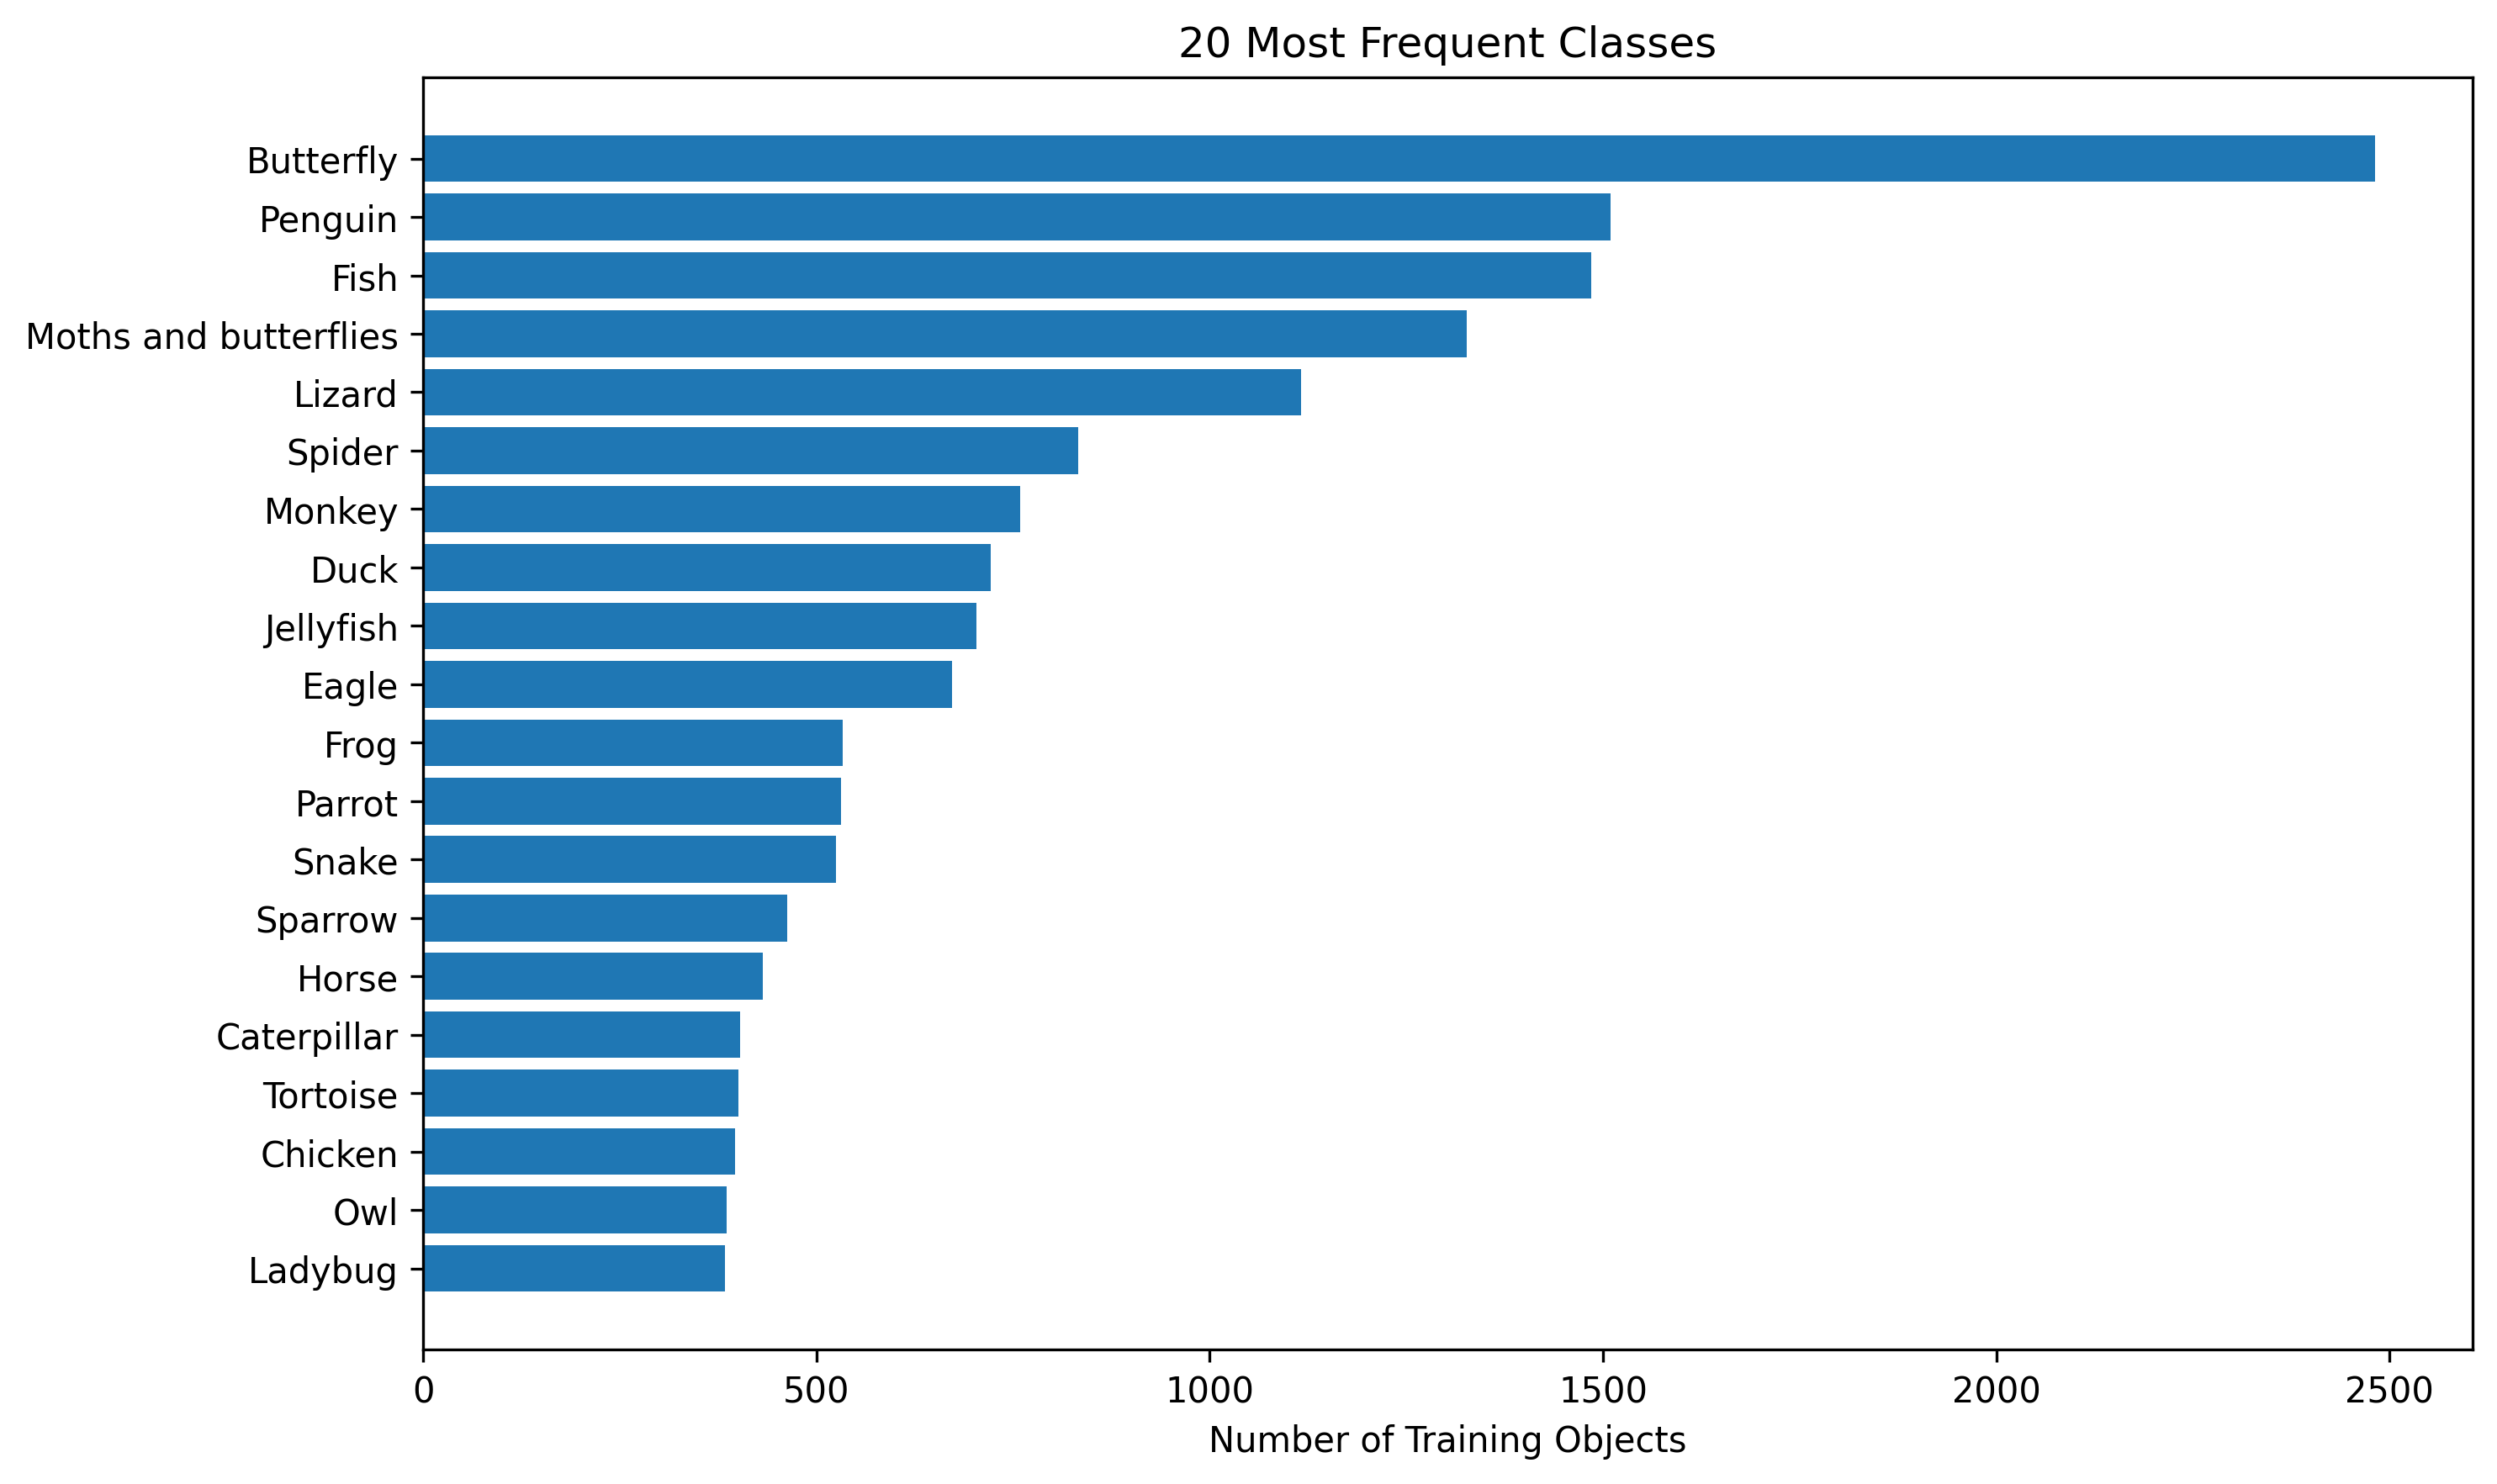

In [34]:
import matplotlib.pyplot as plt
from IPython.display import Image, display

sorted_counts = sorted(
    [(CLASS_NAMES[k], v) for k, v in counts.items()],
    key=lambda x: x[1]
)

bottom20 = sorted_counts[:20]

plt.figure(figsize=(10, 6))
plt.barh(
    [x[0] for x in bottom20],
    [x[1] for x in bottom20]
)
plt.title("20 Least Frequent Classes")
plt.xlabel("Number of Training Objects")
plt.tight_layout()
plt.savefig(
    "/teamspace/studios/this_studio/bottom20_classes.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()

top20 = sorted_counts[-20:]

plt.figure(figsize=(10, 6))
plt.barh(
    [x[0] for x in top20],
    [x[1] for x in top20]
)
plt.title("20 Most Frequent Classes")
plt.xlabel("Number of Training Objects")
plt.tight_layout()
plt.savefig(
    "/teamspace/studios/this_studio/top20_classes.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()

display(Image("/teamspace/studios/this_studio/bottom20_classes.png"))
display(Image("/teamspace/studios/this_studio/top20_classes.png"))

In [35]:
import numpy as np

values = np.array(list(counts.values()))

print("Classes:", len(values))
print("Mean:", values.mean())
print("Median:", np.median(values))
print("Std:", values.std())

print("\nPercentiles")
for p in [10, 25, 50, 75, 90]:
    print(f"{p}%:", np.percentile(values, p))

Classes: 80
Mean: 306.85
Median: 156.0
Std: 397.1803463163806

Percentiles
10%: 51.400000000000006
25%: 81.75
50%: 156.0
75%: 374.25
90%: 704.9000000000002


In [36]:
from pathlib import Path
import shutil
import yaml
from collections import Counter

# ============================================================
# CHANGE THESE TWO PATHS
# ============================================================

OLD_DATASET_ROOT = Path("/teamspace/studios/this_studio/wildlife_yolo")
OLD_YAML_PATH = OLD_DATASET_ROOT / "dataset.yaml"

NEW_DATASET_ROOT = Path("/teamspace/studios/this_studio/wildlife_yolo_72")

# ============================================================
# CLASSES TO REMOVE
# ============================================================

CLASSES_TO_DROP = {
    "Seahorse",
    "Squid",
    "Hamster",
    "Turtle",
    "Bull",
    "Shrimp",
    "Jaguar",
    "Red panda",
}

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
    ".tif",
    ".tiff",
}


# ============================================================
# LOAD ORIGINAL YAML
# ============================================================

if not OLD_YAML_PATH.exists():
    raise FileNotFoundError(f"Could not find YAML file: {OLD_YAML_PATH}")

with open(OLD_YAML_PATH, "r", encoding="utf-8") as file:
    old_yaml = yaml.safe_load(file)

old_names_raw = old_yaml["names"]

# Ultralytics YAML may store names as either a list or a dictionary.
if isinstance(old_names_raw, dict):
    old_names = [
        old_names_raw[index]
        for index in sorted(old_names_raw, key=lambda x: int(x))
    ]
else:
    old_names = list(old_names_raw)

print(f"Original number of classes: {len(old_names)}")

missing_drop_classes = CLASSES_TO_DROP - set(old_names)

if missing_drop_classes:
    raise ValueError(
        "These classes were not found in dataset.yaml:\n"
        + "\n".join(sorted(missing_drop_classes))
    )


# ============================================================
# CREATE OLD-ID -> NEW-ID MAPPING
# ============================================================

dropped_old_ids = {
    old_id
    for old_id, class_name in enumerate(old_names)
    if class_name in CLASSES_TO_DROP
}

kept_classes = [
    class_name
    for class_name in old_names
    if class_name not in CLASSES_TO_DROP
]

old_to_new_id = {}

new_id = 0

for old_id, class_name in enumerate(old_names):
    if old_id not in dropped_old_ids:
        old_to_new_id[old_id] = new_id
        new_id += 1

print("\nClasses being removed:")

for old_id in sorted(dropped_old_ids):
    print(f"{old_id:>2} -> {old_names[old_id]}")

print(f"\nRemaining classes: {len(kept_classes)}")

if len(kept_classes) != 72:
    raise ValueError(
        f"Expected 72 classes after filtering, but found {len(kept_classes)}"
    )


# ============================================================
# RESOLVE SPLIT PATHS
# ============================================================

def resolve_yaml_path(path_value):
    """
    Resolve a path from dataset.yaml.

    Supports paths relative to:
    1. the YAML's `path` field,
    2. the YAML file directory,
    3. absolute paths.
    """

    path_value = Path(path_value)

    if path_value.is_absolute():
        return path_value

    yaml_base_path = old_yaml.get("path")

    if yaml_base_path:
        yaml_base_path = Path(yaml_base_path)

        if not yaml_base_path.is_absolute():
            yaml_base_path = OLD_YAML_PATH.parent / yaml_base_path

        candidate = yaml_base_path / path_value

        if candidate.exists():
            return candidate.resolve()

    return (OLD_YAML_PATH.parent / path_value).resolve()


def get_label_directory(image_directory):
    """
    Convert:
        .../images/train
    into:
        .../labels/train
    """

    parts = list(image_directory.parts)

    if "images" not in parts:
        raise ValueError(
            f"Expected 'images' in split path, but got: {image_directory}"
        )

    image_index = len(parts) - 1 - parts[::-1].index("images")
    parts[image_index] = "labels"

    return Path(*parts)


# ============================================================
# FILTER ONE SPLIT
# ============================================================

def filter_split(split_name, split_yaml_value):
    old_image_dir = resolve_yaml_path(split_yaml_value)
    old_label_dir = get_label_directory(old_image_dir)

    new_image_dir = NEW_DATASET_ROOT / "images" / split_name
    new_label_dir = NEW_DATASET_ROOT / "labels" / split_name

    new_image_dir.mkdir(parents=True, exist_ok=True)
    new_label_dir.mkdir(parents=True, exist_ok=True)

    if not old_image_dir.exists():
        raise FileNotFoundError(
            f"{split_name} image directory does not exist: {old_image_dir}"
        )

    if not old_label_dir.exists():
        raise FileNotFoundError(
            f"{split_name} label directory does not exist: {old_label_dir}"
        )

    statistics = Counter()
    retained_class_counts = Counter()

    image_paths = sorted(
        path
        for path in old_image_dir.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )

    for image_path in image_paths:
        relative_image_path = image_path.relative_to(old_image_dir)
        relative_label_path = relative_image_path.with_suffix(".txt")

        label_path = old_label_dir / relative_label_path

        statistics["original_images"] += 1

        # Images without label files are skipped.
        if not label_path.exists():
            statistics["images_without_labels"] += 1
            continue

        filtered_lines = []

        with open(label_path, "r", encoding="utf-8") as file:
            for line_number, line in enumerate(file, start=1):
                stripped_line = line.strip()

                if not stripped_line:
                    continue

                parts = stripped_line.split()

                if len(parts) < 5:
                    raise ValueError(
                        f"Invalid YOLO annotation in {label_path}, "
                        f"line {line_number}: {stripped_line}"
                    )

                try:
                    old_class_id = int(float(parts[0]))
                except ValueError as error:
                    raise ValueError(
                        f"Invalid class ID in {label_path}, "
                        f"line {line_number}: {parts[0]}"
                    ) from error

                if old_class_id < 0 or old_class_id >= len(old_names):
                    raise ValueError(
                        f"Class ID {old_class_id} in {label_path} is outside "
                        f"the valid range 0-{len(old_names) - 1}"
                    )

                statistics["original_annotations"] += 1

                if old_class_id in dropped_old_ids:
                    statistics["removed_annotations"] += 1
                    continue

                new_class_id = old_to_new_id[old_class_id]

                # Preserve all box coordinates exactly as they were.
                new_line = " ".join([str(new_class_id)] + parts[1:])
                filtered_lines.append(new_line)

                retained_class_counts[new_class_id] += 1
                statistics["retained_annotations"] += 1

        # If all annotations were removed, do not copy the image.
        if not filtered_lines:
            statistics["deleted_empty_images"] += 1
            continue

        destination_image_path = new_image_dir / relative_image_path
        destination_label_path = new_label_dir / relative_label_path

        destination_image_path.parent.mkdir(parents=True, exist_ok=True)
        destination_label_path.parent.mkdir(parents=True, exist_ok=True)

        shutil.copy2(image_path, destination_image_path)

        with open(destination_label_path, "w", encoding="utf-8") as file:
            file.write("\n".join(filtered_lines) + "\n")

        statistics["retained_images"] += 1

    return statistics, retained_class_counts


# ============================================================
# CREATE FILTERED DATASET
# ============================================================

if NEW_DATASET_ROOT.exists():
    raise FileExistsError(
        f"The output directory already exists:\n{NEW_DATASET_ROOT}\n\n"
        "Delete it or choose a different NEW_DATASET_ROOT before running again."
    )

all_statistics = {}
all_class_counts = {}

for split_name in ("train", "val", "test"):
    if split_name not in old_yaml:
        print(f"\nSkipping '{split_name}' because it is not in dataset.yaml")
        continue

    print(f"\nProcessing {split_name}...")

    split_statistics, split_class_counts = filter_split(
        split_name,
        old_yaml[split_name],
    )

    all_statistics[split_name] = split_statistics
    all_class_counts[split_name] = split_class_counts


# ============================================================
# WRITE NEW DATASET.YAML
# ============================================================

new_yaml = {
    "path": str(NEW_DATASET_ROOT.resolve()),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": len(kept_classes),
    "names": kept_classes,
}

new_yaml_path = NEW_DATASET_ROOT / "dataset.yaml"

with open(new_yaml_path, "w", encoding="utf-8") as file:
    yaml.safe_dump(
        new_yaml,
        file,
        sort_keys=False,
        allow_unicode=True,
    )


# ============================================================
# FINAL VALIDATION
# ============================================================

def validate_filtered_dataset():
    discovered_class_ids = set()
    total_label_files = 0
    empty_label_files = 0

    for split_name in ("train", "val", "test"):
        label_dir = NEW_DATASET_ROOT / "labels" / split_name

        if not label_dir.exists():
            continue

        for label_path in label_dir.rglob("*.txt"):
            total_label_files += 1

            lines = [
                line.strip()
                for line in label_path.read_text(encoding="utf-8").splitlines()
                if line.strip()
            ]

            if not lines:
                empty_label_files += 1
                continue

            for line in lines:
                class_id = int(float(line.split()[0]))
                discovered_class_ids.add(class_id)

                if not 0 <= class_id < 72:
                    raise ValueError(
                        f"Invalid remapped class ID {class_id} in {label_path}"
                    )

    print("\nValidation completed.")
    print(f"Label files checked: {total_label_files}")
    print(f"Empty label files: {empty_label_files}")
    print(
        f"Observed class ID range: "
        f"{min(discovered_class_ids)}-{max(discovered_class_ids)}"
    )

    missing_ids = set(range(72)) - discovered_class_ids

    if missing_ids:
        print(f"Warning: these IDs were not found: {sorted(missing_ids)}")
    else:
        print("All class IDs 0-71 were found.")


validate_filtered_dataset()


# ============================================================
# PRINT SUMMARY
# ============================================================

print("\n" + "=" * 65)
print("FILTERING SUMMARY")
print("=" * 65)

for split_name, statistics in all_statistics.items():
    print(f"\n{split_name.upper()}")
    print(f"Original images:       {statistics['original_images']}")
    print(f"Retained images:       {statistics['retained_images']}")
    print(f"Deleted empty images:  {statistics['deleted_empty_images']}")
    print(f"Images without labels: {statistics['images_without_labels']}")
    print(f"Original annotations:  {statistics['original_annotations']}")
    print(f"Removed annotations:   {statistics['removed_annotations']}")
    print(f"Retained annotations:  {statistics['retained_annotations']}")

print("\nNew dataset YAML:")
print(new_yaml_path)

print("\nNew class mapping:")

for old_id, new_id in old_to_new_id.items():
    print(
        f"Old {old_id:>2} -> New {new_id:>2}: "
        f"{old_names[old_id]}"
    )

Original number of classes: 80

Classes being removed:
 2 -> Bull
24 -> Hamster
29 -> Jaguar
54 -> Red panda
59 -> Seahorse
62 -> Shrimp
67 -> Squid
75 -> Turtle

Remaining classes: 72

Processing train...

Processing val...

Processing test...

Validation completed.
Label files checked: 27224
Empty label files: 0
Observed class ID range: 0-71
All class IDs 0-71 were found.

FILTERING SUMMARY

TRAIN
Original images:       19485
Retained images:       19286
Deleted empty images:  199
Images without labels: 0
Original annotations:  24548
Removed annotations:   220
Retained annotations:  24328

VAL
Original images:       2164
Retained images:       2146
Deleted empty images:  18
Images without labels: 0
Original annotations:  2609
Removed annotations:   18
Retained annotations:  2591

TEST
Original images:       6003
Retained images:       5792
Deleted empty images:  211
Images without labels: 0
Original annotations:  6973
Removed annotations:   246
Retained annotations:  6727

New datase

In [37]:
import yaml

yaml_path = "/teamspace/studios/this_studio/wildlife_yolo_72/dataset.yaml"

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

print("nc:", data["nc"])
print("number of names:", len(data["names"]))

nc: 72
number of names: 72


In [38]:
from pathlib import Path

label_dir = Path("/teamspace/studios/this_studio/wildlife_yolo_72/labels")

ids = set()

for txt in label_dir.rglob("*.txt"):
    with open(txt) as f:
        for line in f:
            if line.strip():
                ids.add(int(line.split()[0]))

print("Min ID:", min(ids))
print("Max ID:", max(ids))
print("Unique IDs:", len(ids))

Min ID: 0
Max ID: 71
Unique IDs: 72


In [39]:
from pathlib import Path
from collections import Counter
import yaml

# CHANGE THIS
DATASET = "/teamspace/studios/this_studio/wildlife_yolo_72"

# Load class names
with open(f"{DATASET}/dataset.yaml", "r") as f:
    data = yaml.safe_load(f)

names = data["names"]

counts = Counter()

# Count every object in TRAIN labels
label_dir = Path(DATASET) / "labels" / "train"

for label_file in label_dir.rglob("*.txt"):
    with open(label_file) as f:
        for line in f:
            if line.strip():
                cls = int(line.split()[0])
                counts[cls] += 1

print(f"Classes found: {len(counts)}\n")

for cls_id in sorted(counts):
    print(f"{names[cls_id]:25} {counts[cls_id]}")

Classes found: 72

Bear                      87
Brown bear                100
Butterfly                 2481
Camel                     81
Canary                    106
Caterpillar               403
Cattle                    63
Centipede                 143
Cheetah                   70
Chicken                   396
Crab                      302
Crocodile                 93
Deer                      371
Duck                      722
Eagle                     672
Elephant                  150
Fish                      1485
Fox                       128
Frog                      533
Giraffe                   305
Goat                      196
Goldfish                  150
Goose                     303
Harbor seal               110
Hedgehog                  72
Hippopotamus              71
Horse                     432
Jellyfish                 703
Kangaroo                  95
Koala                     52
Ladybug                   384
Leopard                   112
Lion                      19

In [40]:
from pathlib import Path

label_dir = Path("/teamspace/studios/this_studio/wildlife_yolo_72/labels")

empty = []

for txt in label_dir.rglob("*.txt"):
    if txt.stat().st_size == 0:
        empty.append(txt)

print("Empty label files:", len(empty))

Empty label files: 0


In [41]:
from pathlib import Path

ROOT = Path("/teamspace/studios/this_studio/wildlife_yolo_72")
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

for split in ["train", "val", "test"]:
    image_dir = ROOT / "images" / split
    label_dir = ROOT / "labels" / split

    image_stems = {
        path.relative_to(image_dir).with_suffix("")
        for path in image_dir.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    }

    label_stems = {
        path.relative_to(label_dir).with_suffix("")
        for path in label_dir.rglob("*.txt")
    }

    images_without_labels = image_stems - label_stems
    labels_without_images = label_stems - image_stems

    print(f"\n{split.upper()}")
    print("Images:", len(image_stems))
    print("Labels:", len(label_stems))
    print("Images without labels:", len(images_without_labels))
    print("Labels without images:", len(labels_without_images))


TRAIN
Images: 19286
Labels: 19286
Images without labels: 0
Labels without images: 0

VAL
Images: 2146
Labels: 2146
Images without labels: 0
Labels without images: 0

TEST
Images: 5792
Labels: 5792
Images without labels: 0
Labels without images: 0


In [44]:
from ultralytics import YOLO

model = YOLO(
    "/teamspace/studios/this_studio/runs/yolo26s_512_a100_batch96/weights/best.pt"
)

In [43]:
from pathlib import Path

search_root = Path("/teamspace/studios/this_studio")

best_files = list(search_root.rglob("best.pt"))

for i, path in enumerate(best_files, start=1):
    print(i, path)

1 /teamspace/studios/this_studio/yolo26s_512_a100_batch96/weights/best.pt
2 /teamspace/studios/this_studio/runs/yolo26s_512_a100_batch96/weights/best.pt


In [45]:
results = model.train(
    data="/teamspace/studios/this_studio/wildlife_yolo_72/dataset.yaml",

    epochs=20,
    imgsz=512,
    batch=96,

    workers=8,
    device=0,

    amp=True,
    compile=True,
    cache=False,

    patience=7,
    lr0=0.001,

    project="/teamspace/studios/this_studio/runs",
    name="yolo26s_72class_finetune_v1"
)

Ultralytics 8.4.92 🚀 Python-3.12.11 torch-2.8.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81152MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=96, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=True, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/teamspace/studios/this_studio/wildlife_yolo_72/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/teamspace/studios/this_studio/runs/yolo26s_512_a100_batch96/weights/best.pt, momentum=0.937, mosaic=1.

In [46]:
from ultralytics import YOLO

model = YOLO(
    "/teamspace/studios/this_studio/runs/yolo26s_72class_finetune_v1/weights/best.pt"
)

metrics = model.val(
    data="/teamspace/studios/this_studio/wildlife_yolo_72/dataset.yaml",
    split="test",
    imgsz=512,
    batch=96,
    device=0,
    workers=8
)

Ultralytics 8.4.92 🚀 Python-3.12.11 torch-2.8.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81152MiB)
YOLO26s summary (fused): 122 layers, 9,493,044 parameters, 0 gradients, 20.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1526.5±344.3 MB/s, size: 221.1 KB)
val: Scanning /teamspace/studios/this_studio/wildlife_yolo_72/labels/test... 5792 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5792/5792 992.5it/s 5.8s.0ss
val: New cache created: /teamspace/studios/this_studio/wildlife_yolo_72/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 61/61 2.1it/s 28.8s0.4ss
                   all       5792       6727      0.706      0.661      0.708      0.629
                  Bear         27         30      0.582      0.533      0.562      0.496
            Brown bear         37         42      0.865       0.61      0.755       0.73
             Butterfly        167        178      0.795      0.848      0.875      

In [47]:
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Precision: 0.7064346299552738
Recall: 0.6609093248360188
mAP50: 0.7077983087863399
mAP50-95: 0.629419843870013


In [48]:
import shutil

run_folder = "/teamspace/studios/this_studio/runs/yolo26s_72class_finetune_v1"
zip_output = "/teamspace/studios/this_studio/yolo26s_72class_finetune_v1"

shutil.make_archive(
    zip_output,
    "zip",
    run_folder
)

print("Saved:", zip_output + ".zip")

Saved: /teamspace/studios/this_studio/yolo26s_72class_finetune_v1.zip


In [49]:
from ultralytics import YOLO

model_m = YOLO("yolo26m.pt")

In [ ]:
results_m = model_m.train(
    data="/teamspace/studios/this_studio/wildlife_yolo_72/dataset.yaml",

    epochs=10,
    imgsz=640,

    batch=96,
    device=0,
    workers=8,

    amp=True,
    compile=False,
    cache=False,

    patience=10,

    project="/teamspace/studios/this_studio/runs",
    name="yolo26m_72class_640_10epochs"
)

Ultralytics 8.4.92 🚀 Python-3.12.11 torch-2.8.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81152MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=96, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/teamspace/studios/this_studio/wildlife_yolo_72/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26m_72class_640_10epochs-3, nbs=64, n

  5                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  6                  -1  1   1380352  ultralytics.nn.modules.block.C3k2            [512, 512, 1, True]           
  7                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  8                  -1  1   1380352  ultralytics.nn.modules.block.C3k2            [512, 512, 1, True]           
  9                  -1  1    656896  ultralytics.nn.modules.block.SPPF            [512, 512, 5, 3, True]        
 10                  -1  1    990976  ultralytics.nn.modules.block.C2PSA           [512, 512, 1]                 
 11                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 12             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 13                  -1  1   1642496  ultralytics.nn.modules.block.C3k2            [1024

In [1]:
from ultralytics import YOLO

model = YOLO("yolo26s_72class_finetune_v1/weights/best.pt") 

In [ ]:
  # or the full path to best.pt

results = model.predict(
    source="testing/deer.jpg",
    conf=0.25,
    save=True
)


image 1/1 /home/adol3r/projects/ai/Yolo_Completed_WildLife/testing/deer.jpg: 512x384 1 Deer, 66.8ms
Speed: 5.2ms preprocess, 66.8ms inference, 5.0ms postprocess per image at shape (1, 3, 512, 384)
Results saved to /home/adol3r/projects/ai/Yolo_Completed_WildLife/runs/detect/predict


In [4]:
model.predict(
    source="testing/wildlife.mp4",
    imgsz=640,
    conf=0.25,
    save=True,
    show=False
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/724) /home/adol3r/projects/ai/Yolo_Completed_WildLife/testing/wildlife.mp4: 384x640 (no detections), 70.5ms
video 1/1 (frame 2/724) /home/adol3r/projects/ai/Yolo_Completed_WildLife/testing/wildlife.mp4: 384x640 (no detections), 43.5ms
video 1/1 (frame 3/724) /home/adol3r/projects/ai/Yolo_Completed_WildLife/testing/wildlife.mp4: 384x640 (no detections), 30.7ms
video 1/1 (frame 4/724) /home/adol3r/projects/ai/Yolo_Completed_WildLife/test

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Bear', 1: 'Brown bear', 2: 'Butterfly', 3: 'Camel', 4: 'Canary', 5: 'Caterpillar', 6: 'Cattle', 7: 'Centipede', 8: 'Cheetah', 9: 'Chicken', 10: 'Crab', 11: 'Crocodile', 12: 'Deer', 13: 'Duck', 14: 'Eagle', 15: 'Elephant', 16: 'Fish', 17: 'Fox', 18: 'Frog', 19: 'Giraffe', 20: 'Goat', 21: 'Goldfish', 22: 'Goose', 23: 'Harbor seal', 24: 'Hedgehog', 25: 'Hippopotamus', 26: 'Horse', 27: 'Jellyfish', 28: 'Kangaroo', 29: 'Koala', 30: 'Ladybug', 31: 'Leopard', 32: 'Lion', 33: 'Lizard', 34: 'Lynx', 35: 'Magpie', 36: 'Monkey', 37: 'Moths and butterflies', 38: 'Mouse', 39: 'Mule', 40: 'Ostrich', 41: 'Otter', 42: 'Owl', 43: 'Panda', 44: 'Parrot', 45: 'Penguin', 46: 'Pig', 47: 'Polar bear', 48: 'Rabbit', 49: 'Raccoon', 50: 'Raven', 51: 'Rhinoceros', 52: 'Scorpion', 53: 'Sea lion', 54: 'Sea turtle', 55: 'Shark', 56: 'Sheep', 57: 'Snail', 58: 'Snake'

In [ ]:
model.predict(
    source="testing/wildlife2.mp4",
    imgsz=640,
    conf=0.25,
    save=True,
    show=False
)